# THESAN-Zoom High Redshift Clump


## Introduction

This project is inspired by the observational finding that the high redshift clumps have lower metallicities than the host galaxy. (See https://ui.adsabs.harvard.edu/abs/2025ApJ...991..188E/abstract and https://ui.adsabs.harvard.edu/abs/2025ApJ...979...14S/abstract).

To see such behavior is also happening in the simulations, we started look at the THSAN-Zoom clump catalog produced by Zihao (See https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2675W/abstract).

But first, I need to understand what kind of data is saved in the catalog. So I started reading the THESAN-Zoom paper (Wang et al. 2025).

> We use CLOUDPHINDER (see D. Guszejnov et al. 2019 for its first application) to identify scattered regions within galaxies that are either actively forming stars or have the potential to do so. 

> First, in addition to gaseous structures, we incorporate young stars as an additional component of GMCs.

> Secondly, target gas cells must either have a number density exceeding 100 cm$^{−3}$ or a thermal Jeans length smaller than the cell size (consistent with the star formation criteria of the simulations).

> In addition, we limit the gas temperature to below 1000 K.

> To ensure that the identified GMCs are well resolved, we discard clouds that contain fewer than 30 elements, approximately corresponding to the number of gas cells within one gravitational softening length.




## Clump Catalog

I got the catalog from Zihao. And these are the contents in it.

> The GMC catalog is structured as follows:
> 
> 'GMC_alpha{}_n{}':  # records the setup of CloudPhinder
> 
>	Run: run identifiers (target galaxy, zoom factor), e.g., 'g39z4'
> 
>	HaloID: host group ID (central only)
> 
>	Snapshot: snapshot number
> 
>	CenterPosition: center of mass relative to the group center ['GroupPos'] # kpc
> 
>	EffectiveRadius # kpc
> 
>	GasMass # M_sun
> 
>	StellarMass # M_sun
> 
>	X_Fraction: mass-weighted gas metal fraction of element X
> 
>	X_Fraction_sfr: instantaneous-SFR-weighted gas metal fraction of X
> 
>	SFR_inst: instantaneous SFR # M_sun/yr
> 
>	SFR_yso:  3Myr-averaged SFR # M_sun/yr
> 
>	Number_of_Particles:	total number of component stellar particles or gaseous cell # Filter out unresolved GMC using > 30ish


Now I will read the catalog. I am not sure what HaloID means yet but I will figure it out. I might need a clump's distance from the group center (host galaxy). 

In [1]:
import os
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d

In [2]:
fname = "./gmc_catalog/gmc_output.hdf5"
group_name = "GMC_alpha20_n100"

In [4]:
with h5py.File(fname, "r") as f:
    g = f[group_name]
    print(f"Datasets in {group_name}:")
    for key in g.keys():
        print("  ", key, g[key].shape)

def load_gmc_catalog_df(filename, group_name):
    data = {}

    with h5py.File(filename, "r") as f:
        g = f[group_name]

        for key in g.keys():
            arr = g[key][()]

            # Decode byte strings
            if arr.dtype.kind in ["S", "O"]:
                arr = arr.astype(str)

            # Handle vector quantities (e.g. CenterPosition)
            if isinstance(arr, np.ndarray) and arr.ndim == 2:
                for i in range(arr.shape[1]):
                    data[f"{key}_{i}"] = arr[:, i]
            else:
                data[key] = arr

    return pd.DataFrame(data)

Datasets in GMC_alpha20_n100:
   C_Fraction (53651,)
   C_Fraction_sfr (53651,)
   CenterPosition (53651, 3)
   EffectiveRadius (53651,)
   Fe_Fraction (53651,)
   Fe_Fraction_sfr (53651,)
   GasMass (53651,)
   H_Fraction (53651,)
   H_Fraction_sfr (53651,)
   HaloID (53651,)
   He_Fraction (53651,)
   He_Fraction_sfr (53651,)
   Mg_Fraction (53651,)
   Mg_Fraction_sfr (53651,)
   N_Fraction (53651,)
   N_Fraction_sfr (53651,)
   Ne_Fraction (53651,)
   Ne_Fraction_sfr (53651,)
   Number_of_Particles (53651,)
   O_Fraction (53651,)
   O_Fraction_sfr (53651,)
   Run (53651,)
   SFR_inst (53651,)
   SFR_yso (53651,)
   Si_Fraction (53651,)
   Si_Fraction_sfr (53651,)
   Snapshot (53651,)
   StellarMass (53651,)
   VirialParameter (53651,)


In [5]:
df = load_gmc_catalog_df(fname, group_name)

Z = (
    df["C_Fraction"] +
    df["N_Fraction"] +
    df["O_Fraction"] +
    df["Ne_Fraction"] +
    df["Mg_Fraction"] +
    df["Si_Fraction"] +
    df["Fe_Fraction"]
)

Z_sfr = (
    df["C_Fraction_sfr"] +
    df["N_Fraction_sfr"] +
    df["O_Fraction_sfr"] +
    df["Ne_Fraction_sfr"] +
    df["Mg_Fraction_sfr"] +
    df["Si_Fraction_sfr"] +
    df["Fe_Fraction_sfr"]
)

df["Z"] = Z
df["Z_sfr"] = Z_sfr

In [6]:
df_g39z4 = df.query("Run == 'g39z4'")

In [7]:
with pd.option_context('display.max_columns', None):
    display(df_g39z4.dropna())

,C_Fraction,C_Fraction_sfr,CenterPosition_0,CenterPosition_1,CenterPosition_2,EffectiveRadius,Fe_Fraction,Fe_Fraction_sfr,GasMass,H_Fraction,H_Fraction_sfr,HaloID,He_Fraction,He_Fraction_sfr,Mg_Fraction,Mg_Fraction_sfr,N_Fraction,N_Fraction_sfr,Ne_Fraction,Ne_Fraction_sfr,Number_of_Particles,O_Fraction,O_Fraction_sfr,Run,SFR_inst,SFR_yso,Si_Fraction,Si_Fraction_sfr,Snapshot,StellarMass,VirialParameter,Z,Z_sfr
34992,0.000006,0.000007,-0.184062,0.566459,0.476218,0.052659,6.950784e-07,7.271732e-07,2.007278e+06,0.760000,0.760000,1,0.240089,0.240097,9.730603e-07,9.814299e-07,1.413037e-07,1.458578e-07,0.000008,0.000009,184,0.000076,0.000080,g39z4,0.020121,28.486875,0.000001,0.000001,2,8.546062e+04,6.152065,0.000093,0.000098
35009,0.000007,0.000006,0.017479,-0.088206,-0.043080,0.018102,1.896373e-06,1.365305e-06,4.125724e+05,0.759993,0.759994,1,0.240097,0.240085,1.083714e-06,9.736416e-07,1.217099e-06,9.653249e-07,0.000008,0.000007,37,0.000068,0.000064,g39z4,0.028144,0.000000,0.000002,0.000002,4,0.000000e+00,1.385422,0.000089,0.000082
35012,0.000007,0.000007,0.092010,-0.117780,-0.044620,0.007174,1.434672e-06,1.324554e-06,1.128630e+05,0.759995,0.759996,1,0.240102,0.240099,1.177645e-06,1.148631e-06,9.851098e-07,9.193495e-07,0.000009,0.000008,10,0.000076,0.000075,g39z4,0.015795,0.000000,0.000002,0.000002,4,0.000000e+00,1.580049,0.000098,0.000095
35014,0.000024,0.000020,0.054862,-0.029599,0.006829,0.094020,7.324085e-06,6.143372e-06,8.089367e+06,0.759997,0.759998,1,0.240277,0.240253,4.232591e-06,3.390156e-06,1.628227e-06,1.451124e-06,0.000025,0.000023,838,0.000234,0.000212,g39z4,0.680846,386.427000,0.000008,0.000006,5,1.159281e+06,7.374960,0.000304,0.000272
35015,0.000031,0.000035,-0.084783,-0.021542,-0.171264,0.068049,9.310994e-06,1.024245e-05,5.710924e+06,0.759997,0.759997,1,0.240323,0.240356,5.829732e-06,6.394697e-06,1.741627e-06,1.984549e-06,0.000030,0.000034,560,0.000289,0.000331,g39z4,0.160984,164.261500,0.000011,0.000013,5,4.927845e+05,11.300545,0.000378,0.000431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53640,0.004109,0.004189,-5.295923,0.975025,1.254781,0.011309,1.160207e-03,1.191197e-03,3.950657e+04,0.758490,0.758490,0,0.258931,0.258944,2.457635e-04,2.501768e-04,7.373588e-04,7.377267e-04,0.001122,0.001123,5,0.008759,0.008826,g39z4,0.007358,9.363462,0.000896,0.000916,186,2.809039e+04,2.980792,0.017029,0.017233
53643,0.001706,0.001702,0.448435,0.034709,-0.313144,0.005565,4.229194e-04,4.216491e-04,3.818154e+04,0.759196,0.759195,0,0.250077,0.250081,1.070701e-04,1.067454e-04,4.160856e-04,4.163023e-04,0.000637,0.000637,6,0.003855,0.003848,g39z4,0.054751,7.724035,0.000317,0.000316,186,2.317211e+04,17.549197,0.007461,0.007448
53644,0.002396,0.002373,0.262830,0.916088,0.299264,0.006447,6.119582e-04,6.056654e-04,6.056641e+04,0.758631,0.758631,0,0.256290,0.256292,1.302060e-04,1.288344e-04,7.390152e-04,7.390775e-04,0.000958,0.000958,4,0.005140,0.005104,g39z4,0.053866,0.000000,0.000441,0.000437,186,0.000000e+00,7.400037,0.010416,0.010345
53646,0.003323,0.003305,-3.242712,-5.574090,-1.904025,0.014693,7.525253e-04,7.484799e-04,5.797148e+04,0.759037,0.759036,0,0.253418,0.253403,1.918409e-04,1.907712e-04,5.371123e-04,5.372408e-04,0.000852,0.000851,4,0.006697,0.006677,g39z4,0.013735,0.000000,0.000596,0.000592,186,0.000000e+00,16.625380,0.012951,0.012902


12146

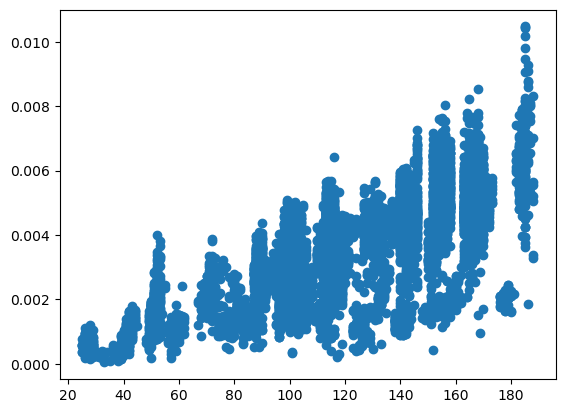

In [16]:
df_target = df.query("Run == 'g205z4'") #df_g39z4 g205z4
plt.scatter(df_target["Snapshot"],df_target["Z"])
len(df_target)

In [17]:
df_target = df_target.query("HaloID == 0")
df_target

,C_Fraction,C_Fraction_sfr,CenterPosition_0,CenterPosition_1,CenterPosition_2,EffectiveRadius,Fe_Fraction,Fe_Fraction_sfr,GasMass,H_Fraction,...,Run,SFR_inst,SFR_yso,Si_Fraction,Si_Fraction_sfr,Snapshot,StellarMass,VirialParameter,Z,Z_sfr
22889,0.000073,0.000069,1.477400,2.149876,0.048132,0.032015,0.000037,0.000036,990512.500000,0.759970,...,g205z4,0.046046,20.947000,0.000030,0.000029,56,62841.000000,5.442851,0.000656,0.000628
22890,0.000077,0.000074,1.549954,2.166503,0.121946,0.035541,0.000037,0.000036,576016.062500,0.759970,...,g205z4,0.102134,106.881812,0.000031,0.000030,56,320645.437500,19.725396,0.000718,0.000709
22891,0.000107,0.000107,1.062118,1.426867,0.388420,0.024823,0.000045,0.000045,450400.625000,0.759922,...,g205z4,0.007125,4.358073,0.000038,0.000038,56,13074.218750,5.941991,0.001001,0.001008
22892,0.000110,0.000108,3.272823,4.438310,-0.668133,0.018319,0.000050,0.000049,242366.390625,0.759938,...,g205z4,0.052864,12.243922,0.000040,0.000039,56,36731.765625,4.174096,0.001010,0.001008
22893,0.000102,NaN,1.053318,1.412264,0.364623,0.006678,0.000046,NaN,43932.144531,0.759908,...,g205z4,0.000000,0.000000,0.000037,NaN,56,0.000000,13.490697,0.000953,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34987,0.001296,NaN,-1.527781,-0.162025,-0.782692,0.006478,0.000390,NaN,46326.570312,0.759487,...,g205z4,0.000000,0.000000,0.000255,NaN,158,0.000000,8.681145,0.005948,NaN
34988,0.001050,NaN,-2.376773,1.008921,0.412214,0.013356,0.000357,NaN,45925.863281,0.759539,...,g205z4,0.000000,0.000000,0.000234,NaN,158,0.000000,19.618953,0.005165,NaN
34989,0.001246,NaN,-1.740525,-0.497685,-0.778429,0.006136,0.000393,NaN,45535.496094,0.759505,...,g205z4,0.000000,0.000000,0.000259,NaN,158,0.000000,14.185767,0.005823,NaN
34990,0.001146,NaN,-1.811216,0.697122,0.385326,0.006210,0.000375,NaN,41039.789062,0.759497,...,g205z4,0.000000,0.000000,0.000246,NaN,158,0.000000,18.587656,0.005422,NaN


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


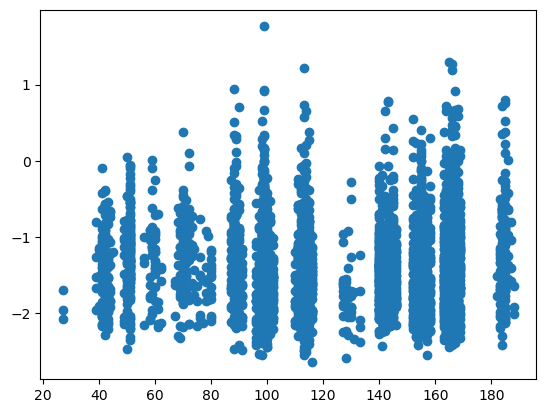

In [19]:
plt.scatter(df_target["Snapshot"],np.log10(df_target["SFR_inst"]))

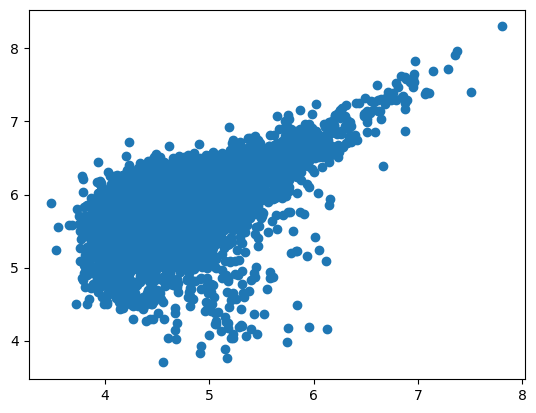

In [20]:
plt.scatter(np.log10(df_target["StellarMass"]),np.log10(df_target["GasMass"]))

---


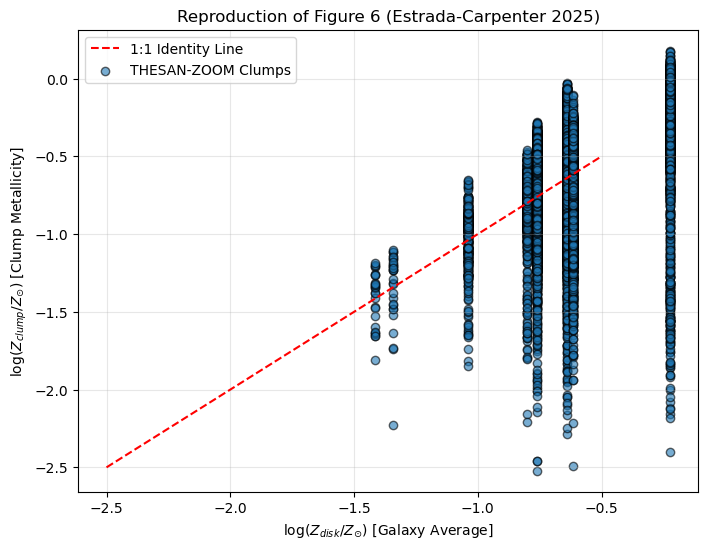

Goal Achieved: Figure 6 has been generated and saved as 'reproduced_figure6.png'


In [ ]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
fname = "./gmc_catalog/gmc_output.hdf5"
group_name = "GMC_alpha20_n100"
fname = "./gmc_catalog/gmc_output.hdf5"
group_name = "GMC_alpha20_n100"
def load_catalog(filename, group):
    with h5py.File(filename, "r") as f:
        g = f[group]
        data = {k: g[k][()] for k in g.keys() if len(g[k].shape) <= 1}
    return pd.DataFrame(data)
df = load_catalog(fname, group_name)
if df is not None:
    metal_cols = ['C_Fraction', 'N_Fraction', 'O_Fraction', 'Ne_Fraction', 'Mg_Fraction', 'Si_Fraction', 'Fe_Fraction']
    df['Total_Z'] = df[metal_cols].sum(axis=1)
    z_sun = 0.0134
    df['log_Z_Zsun'] = np.log10(df['Total_Z'] / z_sun + 1e-10)
    df_filtered = df[df['Number_of_Particles'] > 30].copy()
    df_filtered['Run'] = df_filtered['Run'].str.decode('utf-8')
    host_metallicity = df_filtered.groupby('Run')['log_Z_Zsun'].transform('mean')
    df_filtered['Host_Disk_Z'] = host_metallicity
    plt.figure(figsize=(8, 6))
    lims = [-2.5, -0.5]
    plt.plot(lims, lims, color='red', linestyle='--', label='1:1 Identity Line')
    plt.scatter(df_filtered['Host_Disk_Z'], df_filtered['log_Z_Zsun'], 
                alpha=0.6, edgecolors='k', label='THESAN-ZOOM Clumps')
    plt.xlabel('$\log(Z_{disk} / Z_{\odot})$ [Galaxy Average]')
    plt.ylabel('$\log(Z_{clump} / Z_{\odot})$ [Clump Metallicity]')
    plt.title('Reproduction of Figure 6 (Estrada-Carpenter 2025)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('reproduced_figure6.png', dpi=300)
    plt.show()
    print("Goal Achieved: Figure 6 has been generated and saved as 'reproduced_figure6.png'")


In [32]:
host_metallicity = df_filtered.groupby('Run')['log_Z_Zsun'].transform('mean')

# Group by the specific galaxy at the specific time step
host_metallicity = df_filtered.groupby(['Run', 'Snapshot', 'HaloID'])['log_Z_Zsun'].transform('mean')
df_filtered['Host_Disk_Z'] = host_metallicity

Found 3185 diluted clumps and 26000 normal/enriched clumps.

--- Median Physical Properties ---
               GasMass  StellarMass  SFR_inst  VirialParameter
Is_Diluted                                                    
False      685696.3438   45537.0625    0.0355           9.3822
True       671652.0625   55874.5625    0.0344           8.8170


/var/folders/9q/lkjfsz1s60x18g5s7xh0xwzw0000gn/T/ipykernel_27515/1930348172.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Diluted', y='GasMass', data=df_filtered, palette='Set2')
/var/folders/9q/lkjfsz1s60x18g5s7xh0xwzw0000gn/T/ipykernel_27515/1930348172.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Diluted', y='SFR_inst', data=df_filtered, palette='Set2')


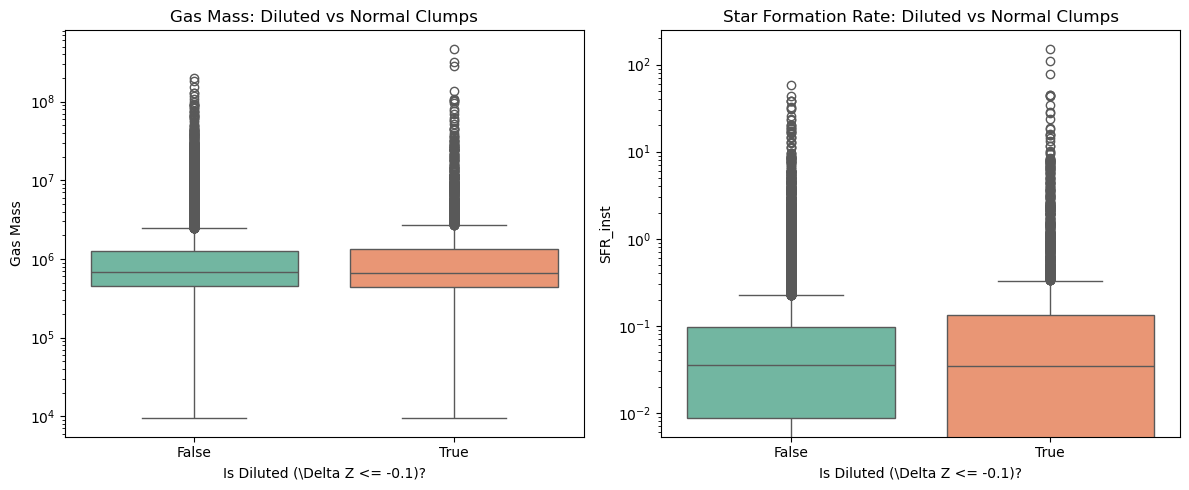

In [33]:
import seaborn as sns

# 1. Apply the corrected grouping to get accurate Host Disk Metallicity
df_filtered['Host_Disk_Z'] = df_filtered.groupby(['Run', 'Snapshot', 'HaloID'])['log_Z_Zsun'].transform('mean')

# 2. Calculate the specific Metallicity Offset (Delta Z) for each clump
df_filtered['Delta_Z'] = df_filtered['log_Z_Zsun'] - df_filtered['Host_Disk_Z']

# 3. Isolate the populations based on the JWST -0.1 dex threshold
df_filtered['Is_Diluted'] = df_filtered['Delta_Z'] <= -0.1

# Split into two distinct DataFrames for deeper analysis later
diluted_clumps = df_filtered[df_filtered['Is_Diluted']].copy()
normal_clumps = df_filtered[~df_filtered['Is_Diluted']].copy()

print(f"Found {len(diluted_clumps)} diluted clumps and {len(normal_clumps)} normal/enriched clumps.")

# ---------------------------------------------------------
# 4. Compare their Physical Drivers
# ---------------------------------------------------------
# We want to see if diluted clumps have more gas, form more stars, or have different kinematics.
physical_cols = ['GasMass', 'StellarMass', 'SFR_inst', 'VirialParameter']

# Calculate the median values for both groups to avoid extreme outliers skewing the data
comparison = df_filtered.groupby('Is_Diluted')[physical_cols].median()
print("\n--- Median Physical Properties ---")
print(comparison)

# ---------------------------------------------------------
# 5. Visualizing the Physical Differences
# ---------------------------------------------------------
# A boxplot is the best way to see the difference in distributions
plt.figure(figsize=(12, 5))

# Plot 1: Gas Mass Comparison
plt.subplot(1, 2, 1)
sns.boxplot(x='Is_Diluted', y='GasMass', data=df_filtered, palette='Set2')
plt.yscale('log')
plt.title('Gas Mass: Diluted vs Normal Clumps')
plt.xlabel('Is Diluted (\Delta Z <= -0.1)?')
plt.ylabel('Gas Mass')

# Plot 2: Instantaneous Star Formation Rate Comparison
plt.subplot(1, 2, 2)
sns.boxplot(x='Is_Diluted', y='SFR_inst', data=df_filtered, palette='Set2')
plt.yscale('log')
plt.title('Star Formation Rate: Diluted vs Normal Clumps')
plt.xlabel('Is Diluted (\Delta Z <= -0.1)?')
plt.ylabel('SFR_inst')

plt.tight_layout()
plt.show()

In [35]:
import h5py
import pandas as pd
import numpy as np
fname = "./gmc_catalog/gmc_output.hdf5"
group_name = "GMC_alpha20_n100"
def load_catalog(filename, group):
    try:
        with h5py.File(filename, "r") as f:
            if group not in f:
                print(f"Error: Group '{group}' not found.")
                return None
            g = f[group]
            data = {} 
            for key in g.keys():
                if len(g[key].shape) <= 1:
                    data[key] = g[key][()]
                else:
                    continue 
            return pd.DataFrame(data)
    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        return None
df = load_catalog(fname, group_name)
if df is not None:
    metal_columns = [
        'C_Fraction', 'N_Fraction', 'O_Fraction', 
        'Ne_Fraction', 'Mg_Fraction', 'Si_Fraction', 'Fe_Fraction'
    ]
    df['Total_Z'] = df[metal_columns].sum(axis=1)
    z_sun = 0.0134
    df['log_Z_Zsun'] = np.log10(df['Total_Z'] / z_sun + 1e-10)
    df_filtered = df[df['Number_of_Particles'] > 30].copy()
    print(f"Successfully loaded {len(df_filtered)} resolved clumps.")
    print("\n--- Figure 6 Data Preview ---")
    cols_to_show = ['Run', 'StellarMass', 'SFR_inst', 'Total_Z', 'log_Z_Zsun']
    print(df_filtered[cols_to_show].head())

else:
    print("Failed to load data. Please check your folder structure.")
df_filtered['Run'] = df_filtered['Run'].str.decode('utf-8')
pd.options.display.float_format = '{:.4f}'.format
print(df_filtered[cols_to_show].head())

Successfully loaded 29185 resolved clumps.

--- Figure 6 Data Preview ---
          Run  StellarMass  SFR_inst  Total_Z  log_Z_Zsun
3  b'g5760z4'  287077.7500    0.1943   0.0007     -1.2626
4  b'g5760z4'  175416.0000    0.0153   0.0004     -1.5326
5  b'g5760z4'  151612.3750    0.0625   0.0004     -1.5180
6  b'g5760z4'  171721.1875    0.1866   0.0007     -1.2643
7  b'g5760z4'       0.0000    0.0095   0.0007     -1.2677
       Run  StellarMass  SFR_inst  Total_Z  log_Z_Zsun
3  g5760z4  287077.7500    0.1943   0.0007     -1.2626
4  g5760z4  175416.0000    0.0153   0.0004     -1.5326
5  g5760z4  151612.3750    0.0625   0.0004     -1.5180
6  g5760z4  171721.1875    0.1866   0.0007     -1.2643
7  g5760z4       0.0000    0.0095   0.0007     -1.2677


In [15]:
import h5py
import pandas as pd
import numpy as np
fname = "./gmc_catalog/gmc_output.hdf5"
group_name = "GMC_alpha20_n100"
def load_catalog(filename, group):
    try:
        with h5py.File(filename, "r") as f:
            if group not in f:
                print(f"Error: Group '{group}' not found.")
                return None
            g = f[group]
            data = {} 
            for key in g.keys():
                if len(g[key].shape) <= 1:
                    data[key] = g[key][()]
                else:
                    continue 
            return pd.DataFrame(data)
    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        return None
df = load_catalog(fname, group_name)
if df is not None:
    metal_columns = [
        'C_Fraction', 'N_Fraction', 'O_Fraction', 
        'Ne_Fraction', 'Mg_Fraction', 'Si_Fraction', 'Fe_Fraction'
    ]
    df['Total_Z'] = df[metal_columns].sum(axis=1)
    z_sun = 0.0134
    df['log_Z_Zsun'] = np.log10(df['Total_Z'] / z_sun + 1e-10)
    df_filtered = df[df['Number_of_Particles'] > 30].copy()
    print(f"Successfully loaded {len(df_filtered)} resolved clumps.")
    print("\n--- Figure 6 Data Preview ---")
    cols_to_show = ['Run', 'StellarMass', 'SFR_inst', 'Total_Z', 'log_Z_Zsun']
    print(df_filtered[cols_to_show].head())

else:
    print("Failed to load data. Please check your folder structure.")
df_filtered['Run'] = df_filtered['Run'].str.decode('utf-8')
pd.options.display.float_format = '{:.4f}'.format
print(df_filtered[cols_to_show].head())


Successfully loaded 29185 resolved clumps.

--- Figure 6 Data Preview ---
          Run  StellarMass  SFR_inst   Total_Z  log_Z_Zsun
3  b'g5760z4'  287077.7500  0.194330  0.000732   -1.262575
4  b'g5760z4'  175416.0000  0.015340  0.000393   -1.532561
5  b'g5760z4'  151612.3750  0.062491  0.000407   -1.518033
6  b'g5760z4'  171721.1875  0.186562  0.000729   -1.264340
7  b'g5760z4'       0.0000  0.009542  0.000724   -1.267659
       Run  StellarMass  SFR_inst  Total_Z  log_Z_Zsun
3  g5760z4  287077.7500    0.1943   0.0007     -1.2626
4  g5760z4  175416.0000    0.0153   0.0004     -1.5326
5  g5760z4  151612.3750    0.0625   0.0004     -1.5180
6  g5760z4  171721.1875    0.1866   0.0007     -1.2643
7  g5760z4       0.0000    0.0095   0.0007     -1.2677


In [16]:
import seaborn as sns


In [18]:
#penguins = sns.load_dataset("penguins")
#sns.pairplot(df)

In [19]:
df

,C_Fraction,C_Fraction_sfr,EffectiveRadius,Fe_Fraction,Fe_Fraction_sfr,GasMass,H_Fraction,H_Fraction_sfr,HaloID,He_Fraction,...,Run,SFR_inst,SFR_yso,Si_Fraction,Si_Fraction_sfr,Snapshot,StellarMass,VirialParameter,Total_Z,log_Z_Zsun
0,0.0001,0.0001,0.0158,0.0000,0.0000,188597.2969,0.7600,0.7600,0,0.2407,...,b'g5760z4',0.0068,4.4969,0.0000,0.0000,75,13490.8281,7.4530,0.0007,-1.3128
1,0.0001,0.0001,0.0191,0.0000,0.0000,266440.9062,0.7599,0.7599,0,0.2408,...,b'g5760z4',0.0114,0.0000,0.0000,0.0000,77,0.0000,9.0036,0.0007,-1.3053
2,0.0000,NaN,0.0147,0.0000,NaN,150354.3906,0.7600,NaN,0,0.2404,...,b'g5760z4',0.0000,0.0000,0.0000,NaN,77,0.0000,3.2931,0.0003,-1.6187
3,0.0001,0.0001,0.0520,0.0000,0.0000,1832248.7500,0.7599,0.7599,0,0.2408,...,b'g5760z4',0.1943,95.6926,0.0000,0.0000,78,287077.7500,6.4245,0.0007,-1.2626
4,0.0000,0.0000,0.0347,0.0000,0.0000,1178086.5000,0.7600,0.7600,0,0.2404,...,b'g5760z4',0.0153,58.4720,0.0000,0.0000,78,175416.0000,9.4203,0.0004,-1.5326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53646,0.0033,0.0033,0.0147,0.0008,0.0007,57971.4844,0.7590,0.7590,0,0.2534,...,b'g39z4',0.0137,0.0000,0.0006,0.0006,186,0.0000,16.6254,0.0130,-0.0148
53647,0.0038,NaN,0.0085,0.0008,NaN,48300.8281,0.7590,NaN,0,0.2551,...,b'g39z4',0.0000,0.0000,0.0007,NaN,186,0.0000,19.4750,0.0146,0.0384
53648,0.0008,NaN,0.0075,0.0002,NaN,46671.9648,0.7590,NaN,0,0.2517,...,b'g39z4',0.0000,0.0000,0.0001,NaN,186,0.0000,14.2175,0.0045,-0.4714
53649,0.0013,0.0009,0.0041,0.0003,0.0002,45896.8164,0.7588,0.7588,0,0.2548,...,b'g39z4',0.0269,0.0000,0.0002,0.0002,186,0.0000,16.6601,0.0058,-0.3614


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53651 entries, 0 to 53650
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   C_Fraction           53651 non-null  float64
 1   C_Fraction_sfr       32529 non-null  float64
 2   EffectiveRadius      53651 non-null  float64
 3   Fe_Fraction          53651 non-null  float64
 4   Fe_Fraction_sfr      32529 non-null  float64
 5   GasMass              53651 non-null  float64
 6   H_Fraction           53651 non-null  float64
 7   H_Fraction_sfr       32529 non-null  float64
 8   HaloID               53651 non-null  int64  
 9   He_Fraction          53651 non-null  float64
 10  He_Fraction_sfr      32529 non-null  float64
 11  Mg_Fraction          53651 non-null  float64
 12  Mg_Fraction_sfr      32529 non-null  float64
 13  N_Fraction           53651 non-null  float64
 14  N_Fraction_sfr       32529 non-null  float64
 15  Ne_Fraction          53651 non-null 

In [22]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Show the correlation of all features with a specific column, for example, 'StellarMass'
print(corr_matrix['StellarMass'].sort_values(ascending=False))

StellarMass            1.0000
SFR_yso                1.0000
Number_of_Particles    0.9305
SFR_inst               0.9134
GasMass                0.8702
EffectiveRadius        0.4837
He_Fraction            0.0381
N_Fraction             0.0378
Ne_Fraction            0.0374
VirialParameter        0.0243
N_Fraction_sfr         0.0229
Snapshot               0.0227
He_Fraction_sfr        0.0223
Ne_Fraction_sfr        0.0211
log_Z_Zsun             0.0171
Total_Z                0.0059
C_Fraction             0.0026
O_Fraction             0.0020
Si_Fraction           -0.0023
Fe_Fraction           -0.0026
Mg_Fraction           -0.0093
HaloID                -0.0188
H_Fraction_sfr        -0.0239
H_Fraction            -0.0378
C_Fraction_sfr        -0.0453
O_Fraction_sfr        -0.0525
Si_Fraction_sfr       -0.0540
Fe_Fraction_sfr       -0.0552
Mg_Fraction_sfr       -0.0687
Name: StellarMass, dtype: float64


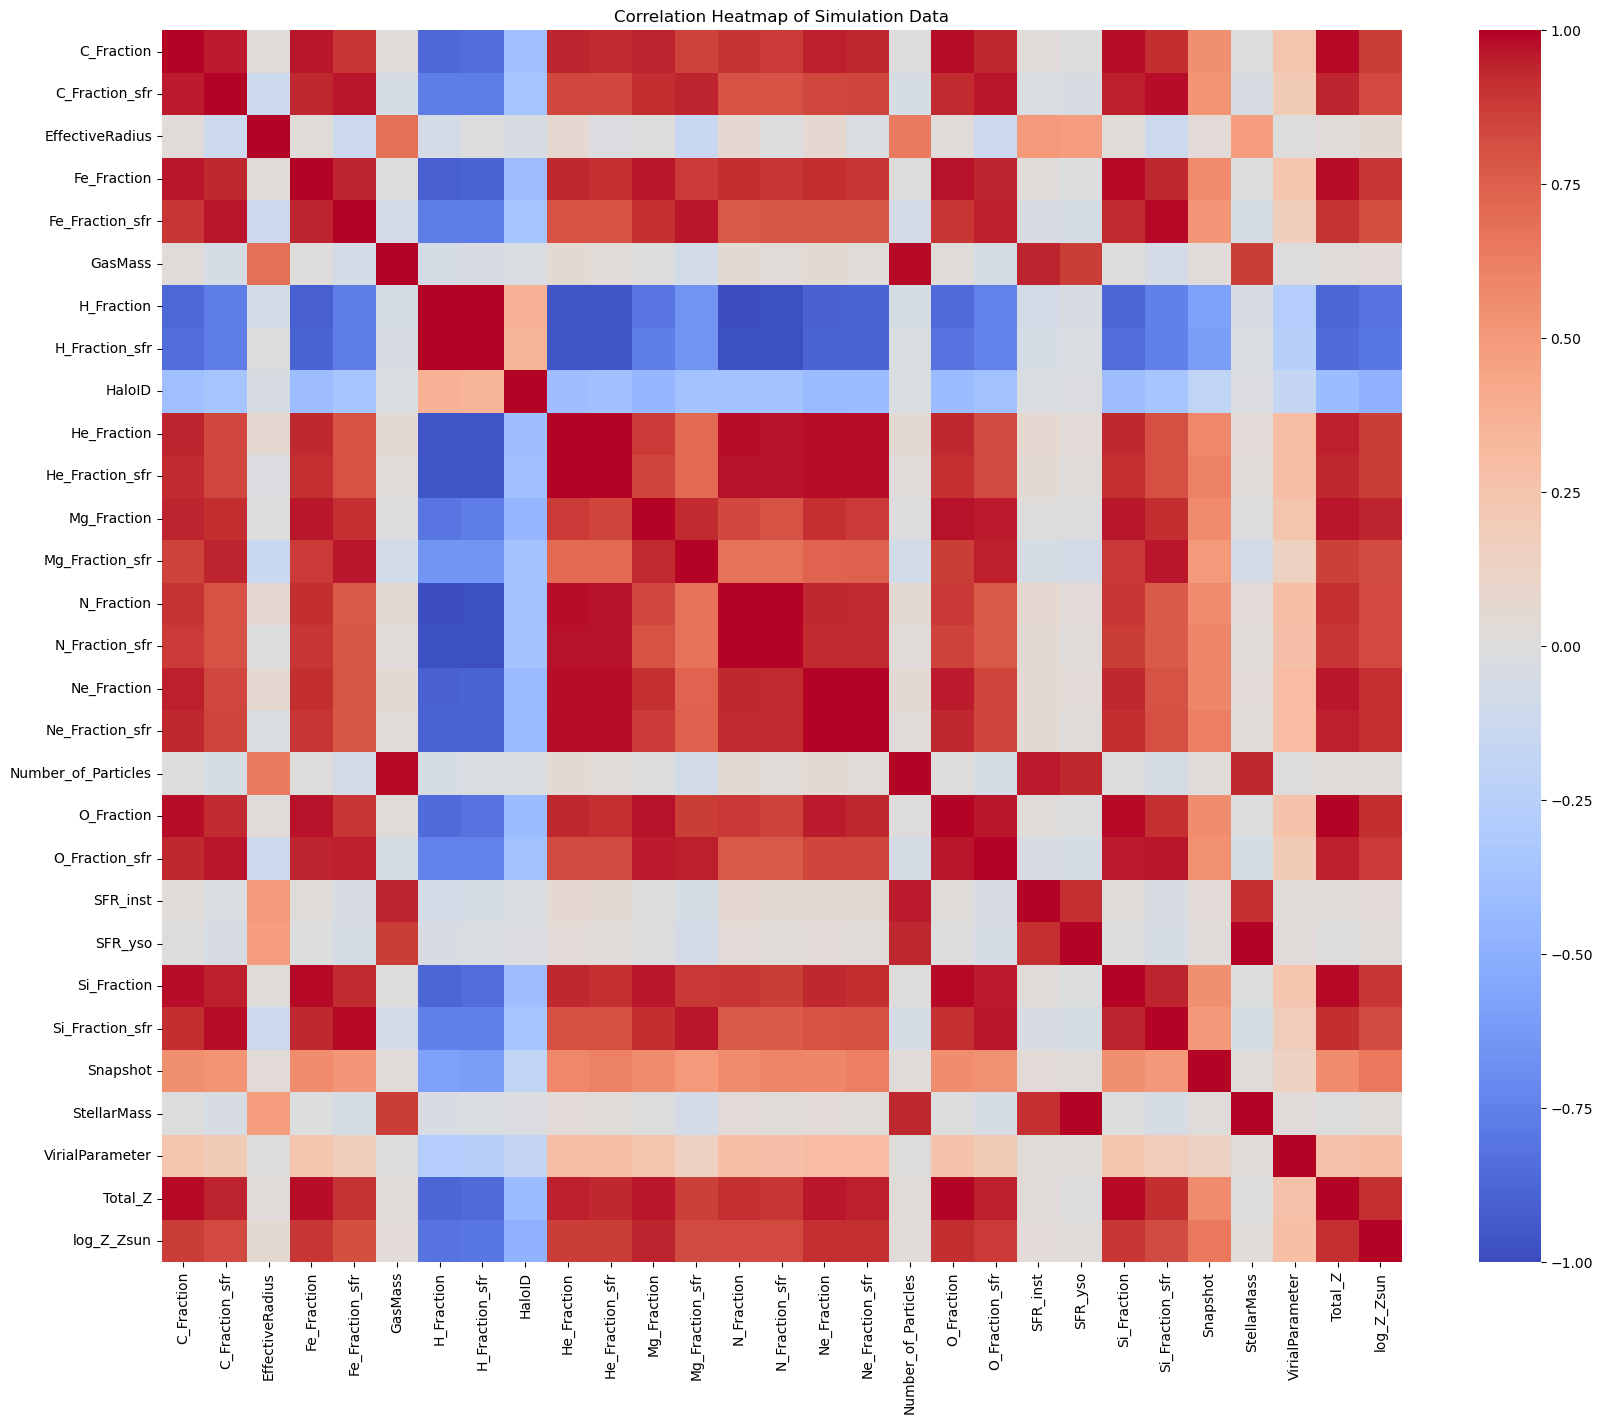

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16)) # Make the plot large enough to read 29x29 columns

# Create the heatmap
sns.heatmap(corr_matrix, 
            annot=False,     # Set to True if you want the numbers printed on the squares (can be cluttered)
            cmap='coolwarm', # Color map: Red = positive, Blue = negative
            vmin=-1, vmax=1, # Correlation limits
            center=0)

plt.title('Correlation Heatmap of Simulation Data')
plt.show()

In [25]:
# Unstack the correlation matrix and sort the values
sorted_pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)

# Filter out self-correlations (where correlation is exactly 1.0)
# and pick a threshold, e.g., stronger than 0.7 or weaker than -0.7
strong_pairs = sorted_pairs[(sorted_pairs != 1.0) & (abs(sorted_pairs) > 0.7)]

# Drop duplicates (since A vs B is the same as B vs A)
strong_pairs = strong_pairs.drop_duplicates()

print("Strongest Correlations:")
print(strong_pairs)

Strongest Correlations:
StellarMass      SFR_yso            1.0000
He_Fraction      He_Fraction_sfr    0.9998
Ne_Fraction      Ne_Fraction_sfr    0.9998
N_Fraction_sfr   N_Fraction         0.9997
H_Fraction       H_Fraction_sfr     0.9997
                                     ...  
H_Fraction_sfr   O_Fraction_sfr    -0.7439
Mg_Fraction_sfr  Ne_Fraction_sfr    0.7427
Ne_Fraction      Mg_Fraction_sfr    0.7419
Mg_Fraction_sfr  He_Fraction_sfr    0.7160
He_Fraction      Mg_Fraction_sfr    0.7155
Length: 196, dtype: float64


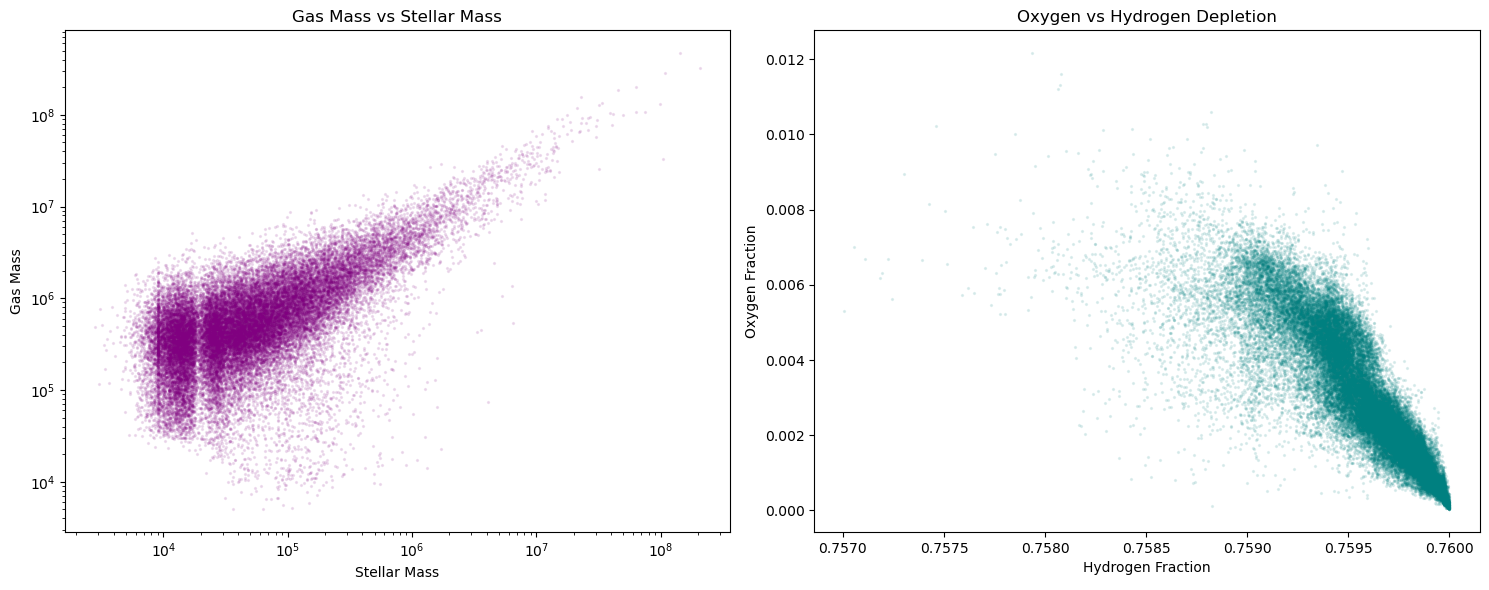

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Mass Relationship
axes[0].scatter(df['StellarMass'], df['GasMass'], alpha=0.1, s=2, color='purple')
axes[0].set_xlabel('Stellar Mass')
axes[0].set_ylabel('Gas Mass')
axes[0].set_title('Gas Mass vs Stellar Mass')
axes[0].set_xscale('log') # Mass is often better viewed on a log scale
axes[0].set_yscale('log')

# Plot 2: Chemistry Relationship
axes[1].scatter(df['H_Fraction'], df['O_Fraction'], alpha=0.1, s=2, color='teal')
axes[1].set_xlabel('Hydrogen Fraction')
axes[1].set_ylabel('Oxygen Fraction')
axes[1].set_title('Oxygen vs Hydrogen Depletion')

plt.tight_layout()
plt.show()

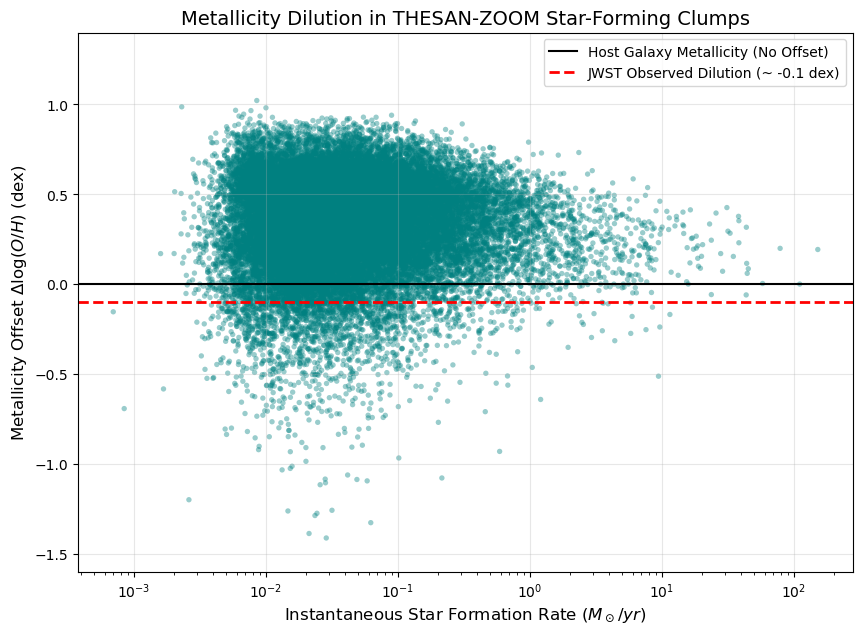

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter out regions that are NOT currently forming stars
sf_clumps = df.dropna(subset=['O_Fraction_sfr', 'H_Fraction_sfr']).copy()

# 2. Calculate the observational gas-phase metallicity: 12 + log(O/H)
# Convert mass fractions to number fractions (O atomic mass ~16, H ~1.008)
sf_clumps['O_H_ratio'] = (sf_clumps['O_Fraction_sfr'] / 16.0) / (sf_clumps['H_Fraction_sfr'] / 1.008)
sf_clumps['Metallicity_obs'] = 12 + np.log10(sf_clumps['O_H_ratio'])

# 3. Identify the "Host Galaxy" vs "Clumps" within each HaloID
# We assume the object with the largest StellarMass in each HaloID is the main disk
idx_main_galaxies = sf_clumps.groupby('HaloID')['StellarMass'].idxmax()

# Create a reference table of the host metallicities
host_metallicities = sf_clumps.loc[idx_main_galaxies, ['HaloID', 'Metallicity_obs']]
host_metallicities = host_metallicities.rename(columns={'Metallicity_obs': 'Host_Metallicity'})

# Merge the host metallicity back into the main dataframe
sf_clumps = sf_clumps.merge(host_metallicities, on='HaloID')

# 4. Filter out the main galaxies so we are ONLY looking at the clumps
clumps_only = sf_clumps[~sf_clumps.index.isin(idx_main_galaxies)].copy()

# 5. Calculate the Metallicity Offset (Delta Z)
clumps_only['Delta_Z'] = clumps_only['Metallicity_obs'] - clumps_only['Host_Metallicity']

# ---------------------------------------------------------
# 6. Recreate the Observational Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 7))

# Plot the clumps
plt.scatter(clumps_only['SFR_inst'], clumps_only['Delta_Z'], 
            alpha=0.4, s=15, c='teal', edgecolors='none')

# Add observational reference lines
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Host Galaxy Metallicity (No Offset)')
plt.axhline(-0.1, color='red', linestyle='--', linewidth=2, label='JWST Observed Dilution (~ -0.1 dex)')

# Formatting
plt.xscale('log')
plt.xlabel(r'Instantaneous Star Formation Rate ($M_\odot / yr$)', fontsize=12)
plt.ylabel(r'Metallicity Offset $\Delta \log(O/H)$ (dex)', fontsize=12)
plt.title('Metallicity Dilution in THESAN-ZOOM Star-Forming Clumps', fontsize=14)
plt.ylim(-1.6, 1.4) # Adjust based on your data spread
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()